In [1]:
# 1. Scikit learn comes with the pre-loaded dataset, load the digits dataset from that collection and write a helper function to plot the image using 
# matplotlib. [Hint: Explore datasets module from scikit learn] 
# 2. Make a train-test split with 20% of the data set aside for testing. Fit a logistic regression model and observe the accuracy. 
# 3. Using scikit learn perform a PCA transformation such that the transformed dataset can explain 95% of the variance in the original dataset. 
# Find out the number of components in the projected subspace. [Hint: Refer to decomposition module of scikit learn] 
# 4. Transform the dataset and fit a logistic regression and observe the accuracy. Compare it with the previous model and comment on the accuracy. 
# [Hint: Project both the train and test samples to the new subspace] 
# 5. Compute the confusion matrix and count the number of instances that have gone wrong. For each wrong sample, plot the digit along with the 
# predicted and original label. 

# sklearn datasets https://scikit-learn.org/stable/api/sklearn.datasets.html

# Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 640x480 with 0 Axes>

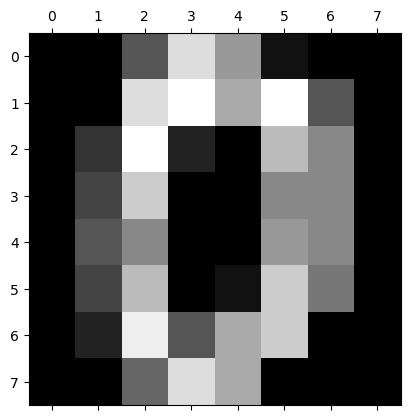

In [3]:
# Read in digits dataset.

from sklearn.datasets import load_digits
digits = load_digits()
#digits = dataF
#print(digits.data.shape)
#print(digits)
import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[0])
plt.show()

In [4]:
X = pd.DataFrame(digits.data, columns=digits.feature_names)

In [5]:
y = digits.target

In [18]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [19]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

C:\Users\SiyaPransh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# import the metrics class
from sklearn import metrics
from sklearn.metrics import accuracy_score

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)
print("Accuracy :")
acc = accuracy_score(y_test,y_pred)
print(acc)

[[42  0  1  0  0  1  0  0  0  0]
 [ 0 41  0  0  1  0  0  0  0  1]
 [ 0  2 38  0  0  0  0  0  0  0]
 [ 0  0  0 46  0  0  0  0  1  1]
 [ 0  1  0  0 47  0  0  0  0  0]
 [ 0  0  0  0  1 41  0  0  0  0]
 [ 0  0  0  0  0  0 42  0  0  0]
 [ 0  0  0  0  1  0  0 54  1  1]
 [ 0  1  0  0  0  2  0  1 41  0]
 [ 0  0  0  0  0  0  0  0  1 40]]
Accuracy :
0.96


Text(0.5, 427.9555555555555, 'Predicted label')

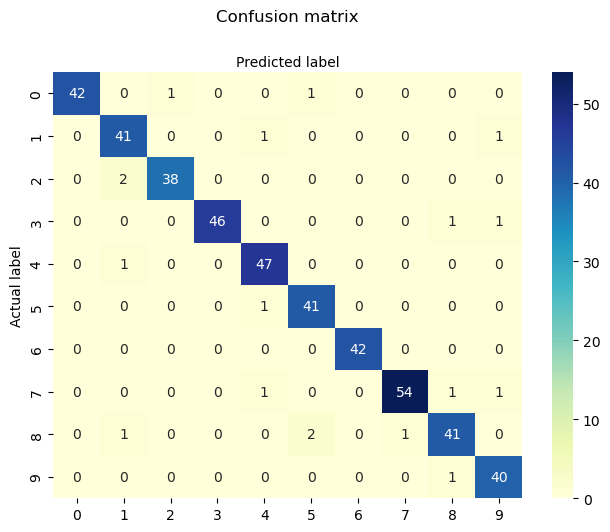

In [21]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [6]:
# 3. Using scikit learn perform a PCA transformation such that the transformed dataset can explain 95% of the variance in the original dataset. 
# Find out the number of components in the projected subspace. [Hint: Refer to decomposition module of scikit learn] 
# 4. Transform the dataset and fit a logistic regression and observe the accuracy. Compare it with the previous model and comment on the accuracy. 
# [Hint: Project both the train and test samples to the new subspace] 
# 5. Compute the confusion matrix and count the number of instances that have gone wrong. For each wrong sample, plot the digit along with the 
# predicted and original label. 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
scaler = StandardScaler()

#print(X.head())
pca.fit(X)
Xx = pca.transform(X)
Xxx = pd.DataFrame(Xx)
Xxx.index = X.index
Xxx.columns = ['PC1','PC2','PC3']
print(Xxx.head())
print(pca.explained_variance_ratio_)

         PC1        PC2       PC3
0  -1.259466 -21.274883  9.463055
1   7.957611  20.768699 -4.439506
2   6.991923   9.955986 -2.958558
3 -15.906105  -3.332464 -9.824372
4  23.306867  -4.269061  5.675129
[0.14890594 0.13618771 0.11794594]


In [7]:
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(Xxx, y, test_size=0.25, random_state=16)

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)
print("Accuracy :")
acc = accuracy_score(y_test,y_pred)
print(acc)

[[44  0  0  0  0  0  0  0  0  0]
 [ 1 24  5  0  0  2  1  6  0  4]
 [ 0  0 31  4  0  3  1  1  0  0]
 [ 0  0  9 32  0  1  0  0  1  5]
 [ 0  2  0  0 46  0  0  0  0  0]
 [ 1  6  0  0  2 12  0  0  7 14]
 [ 0  0  0  0  1  0 41  0  0  0]
 [ 0  6  0  0  2  0  0 47  1  1]
 [ 0  9  7  1  1 17  0  1  8  1]
 [ 0  0  1  8  2  3  0  2  0 25]]
Accuracy :
0.6888888888888889


C:\Users\SiyaPransh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
classification_report = metrics.classification_report(y_pred, y_test)
print("Classification Report\n")
print(classification_report)

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.56      0.51      0.53        47
           2       0.78      0.58      0.67        53
           3       0.67      0.71      0.69        45
           4       0.96      0.85      0.90        54
           5       0.29      0.32      0.30        38
           6       0.98      0.95      0.96        43
           7       0.82      0.82      0.82        57
           8       0.18      0.47      0.26        17
           9       0.61      0.50      0.55        50

    accuracy                           0.69       450
   macro avg       0.68      0.67      0.67       450
weighted avg       0.73      0.69      0.70       450

